In [2]:
import pandas as pd
import numpy as np
from geopy.distance import distance  # 거리 계산을 위한 라이브러리
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import seaborn as sns
import matplotlib.pyplot as plt

In [6]:
# trans_date_trans_time: 거래 일시 (날짜 및 시간)
# cc_num: 카드 번호
# merchant: 가맹점 (상호명)
# category: 카테고리 (업종/분류)
# amt: 거래 금액
# first: 이름 (First Name)
# last: 성 (Last Name)
# gender: 성별
# street: 도로명 주소
# city: 도시
# state: 주 (State)
# zip: 우편번호
# lat: 위도 (고객 거주지 기준)
# long: 경도 (고객 거주지 기준)
# city_pop: 도시 인구수
# job: 직업
# dob: 생년월일
# trans_num: 거래 고유 번호 (ID)
# unix_time: 유닉스 타임스탬프 (숫자형 시간 정보)
# merch_lat: 가맹점 위도
# merch_long: 가맹점 경도
# is_fraud: 사기 여부 (1: 사기 거래, 0: 정상 거래)

In [3]:
# 금융데이터 가져오기
df= pd.read_csv('fraud.csv')

# 컬럼이 많아도 생략하지않고 다 보이도록 설정
pd.set_option('display.max_columns', 50)

In [ ]:
# 데이터 확인
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,NJ,7208,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,NJ,7060,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,MI,48174,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,LA,70808,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0
5,2019-01-01 00:26:22,3598215285024754,fraud_Heidenreich PLC,grocery_pos,207.36,Ashley,Lopez,F,9333 Valentine Point,Bellmore,NY,11710,40.6729,-73.5365,34496,"Librarian, public",1970-10-21,f246ac27c09429ff1e385d4683c79c4d,1325377582,40.202538,-73.859212,0
6,2019-01-01 00:27:45,213141712584544,fraud_Halvorson Group,misc_pos,181.35,Margaret,Curtis,F,742 Oneill Shore,Florence,MS,39073,32.1530,-90.1217,19685,Fine artist,1984-12-24,7bb25a43205191eb7344282b88fc54d3,1325377665,31.939812,-90.726209,0
7,2019-01-01 00:30:49,676372984911,"fraud_Christiansen, Goyette and Schamberger",gas_transport,53.60,Vicki,Mendoza,F,3645 Atkins Island Apt. 238,Esbon,KS,66941,39.7562,-98.4462,242,Tourism officer,1987-07-18,f1566e9623814dd277dfa2a9bf83ea36,1325377849,40.332519,-99.062962,0
8,2019-01-01 00:31:51,4642255475285942,fraud_Ledner-Pfannerstill,gas_transport,102.13,Sabrina,Johnson,F,320 Nicholson Orchard,Thompson,UT,84540,38.9999,-109.6150,46,"Surveyor, minerals",1987-04-23,47238da5b40d126c8abea40a857c7809,1325377911,39.807313,-109.348294,0
9,2019-01-01 00:34:10,3553629419254918,fraud_Stracke-Lemke,grocery_pos,83.07,Sharon,Johnson,F,7202 Jeffrey Mills,Conway,WA,98238,48.3400,-122.3456,85,"Research officer, political party",1984-09-01,9b7a0619dcc5c572dc134f2827ed5a6b,1325378050,48.682111,-122.719904,0


In [9]:
# 글자를 날짜형 데이터로 변환
df['trans_date_trans_time'] = pd.to_datetime(df['trans_date_trans_time'])

# 생년월일컬럼 날짜형으로 변환 **실제 이상거래탐지에서 Age를 중요하게 여김.
df['dob'] = pd.to_datetime(df['dob'])

In [10]:
# 생년월일로 실제나이 계산: 결제 연도 - 출생 연도
df['age'] = df['trans_date_trans_time'].dt.year - df['dob'].dt.year

# 결제시각 추출
df['trans_hour'] = df['trans_date_trans_time'].dt.hour

df.tail()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,trans_hour
491129,2020-12-31 23:56:48,6011109736646996,fraud_Botsford and Sons,home,134.26,Rebecca,Erickson,F,594 Berry Lights Apt. 392,Wilmington,NC,28405,34.2651,-77.8670,186140,English as a second language teacher,1983-02-08,fc860b0d1f89b0b068c9c8db27b6bcc5,1388534208,34.853497,-78.664158,0,37,23
491130,2020-12-31 23:56:57,213112402583773,"fraud_Baumbach, Hodkiewicz and Walsh",shopping_pos,25.49,Ana,Howell,F,4664 Sanchez Common Suite 930,Bradley,SC,29819,34.0326,-82.2027,1523,Research scientist (physical sciences),1984-06-03,0f0c38fe781b317f733b845c0d6ba448,1388534217,35.008839,-81.475156,0,36,23
491131,2020-12-31 23:59:09,3556613125071656,fraud_Hoppe-Parisian,kids_pets,111.84,Jose,Vasquez,M,572 Davis Mountains,Lake Jackson,TX,77566,29.0393,-95.4401,28739,Futures trader,1999-12-27,2090647dac2c89a1d86c514c427f5b91,1388534349,29.661049,-96.186633,0,21,23
491132,2020-12-31 23:59:15,6011724471098086,fraud_Rau-Robel,kids_pets,86.88,Ann,Lawson,F,144 Evans Islands Apt. 683,Burbank,WA,99323,46.1966,-118.9017,3684,Musician,1981-11-29,6c5b7c8add471975aa0fec023b2e8408,1388534355,46.658340,-119.715054,0,39,23
491133,2020-12-31 23:59:34,4170689372027579,fraud_Dare-Marvin,entertainment,38.13,Samuel,Frey,M,830 Myers Plaza Apt. 384,Edmond,OK,73034,35.6665,-97.4798,116001,Media buyer,1993-05-10,1765bb45b3aa3224b4cdcb6e7a96cee3,1388534374,36.210097,-97.036372,0,27,23


In [11]:
# 고객의 위치와 상점 사이의 거리를 km 단위로 계산하여 distance 컬럼에 저장
df['distance'] = df.apply(lambda x: distance((x['lat'], x['long']), (x['merch_lat'], x['merch_long'])).km, axis = 1)

In [12]:
# 소비패턴 분석 (평소지출보다 얼마나 많이 지출했는지 - 단순 고액결제와 사기 구분)
user_avg_amt = df.groupby('cc_num')['amt'].transform('mean')
df['amt_ratio'] = df['amt'] / user_avg_amt

In [13]:
# 가맹점 사기기록 확인
# 해당 가맹점에서 발생한 전체 결제 건수 중 사기 거래(is_fraud=1)가 차지하는 비율
df['merchant_fraud'] = df.groupby('merchant')['is_fraud'].transform('mean')
df.head()

,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,age,trans_hour,distance,amt_ratio,merchant_fraud
0,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,41,0,30.216618,1.912154,0.001212
1,2019-01-01 00:12:34,4956828990005111019,"fraud_Schultz, Simonis and Little",grocery_pos,44.71,Kenneth,Robinson,M,269 Sanchez Rapids,Elizabeth,NJ,7208,40.6747,-74.2239,124967,Operational researcher,1980-12-21,09eff9c806365e2a6be12c1bbab3d70e,1325376754,40.079588,-74.848087,0,39,0,84.714605,0.746934,0.007362
2,2019-01-01 00:17:16,180048185037117,fraud_Kling-Grant,grocery_net,46.28,Mary,Wall,F,2481 Mills Lock,Plainfield,NJ,7060,40.6152,-74.4150,71485,Leisure centre manager,1974-07-19,19e23c6a300c774354417befe4f31f8c,1325377036,40.021888,-74.228188,0,45,0,67.768167,0.529956,0.001919
3,2019-01-01 00:20:15,374930071163758,fraud_Deckow-O'Conner,grocery_pos,64.09,Daniel,Escobar,M,61390 Hayes Port,Romulus,MI,48174,42.2203,-83.3583,31515,Police officer,1971-11-05,6f363661ba6b55889e488dd178f2a0af,1325377215,42.360426,-83.552316,0,48,0,22.322745,0.996458,0.002283
4,2019-01-01 00:23:41,2712209726293386,fraud_Balistreri-Nader,misc_pos,25.58,Jenna,Brooks,F,50872 Alex Plain Suite 088,Baton Rouge,LA,70808,30.4066,-91.1468,378909,"Designer, furniture",1977-02-22,1654da2abfb9e79a5f99167fc9779558,1325377421,29.737426,-90.853194,0,42,0,79.398244,0.281882,0.001534


In [ ]:
# 머신러닝 사기탐지 학습
features = ['category', 'amt', 'gender', 'age', 'trans_hour', 'distance', 'amt_ratio', 'merchant_fraud']
x = df[features].copy()  # 필요한데이터만 사용 
y = df['is_fraud']

In [15]:
# 머신러닝 데이터구조확인
print(x.shape),  # 491,134개행과 8개의 열로 구성
print(y.shape)   # 491,134개행과 , 콤마만표시 = 열의 개수 1 '사기다/아니다'

(491134, 8)
(491134,)


In [16]:
# 데이터타입이 object인 컬럼 확인
x.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 491134 entries, 0 to 491133
Data columns (total 8 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   category        491134 non-null  object 
 1   amt             491134 non-null  float64
 2   gender          491134 non-null  object 
 3   age             491134 non-null  int32  
 4   trans_hour      491134 non-null  int32  
 5   distance        491134 non-null  float64
 6   amt_ratio       491134 non-null  float64
 7   merchant_fraud  491134 non-null  float64
dtypes: float64(4), int32(2), object(2)
memory usage: 26.2+ MB


In [17]:
# object(문자열)에서 숫자로 변환 (카테고리는 종류가 14개라 label인코딩을 고려했으나, 원핫인코딩적용)
x = pd.get_dummies(x, columns=['category', 'gender'], drop_first=True)

In [18]:
# 카테고리 컬럼수는 늘어났으나 업종별 특징을 구분하기에는 탁월함
x.head()

,amt,age,trans_hour,distance,amt_ratio,merchant_fraud,category_food_dining,category_gas_transport,category_grocery_net,category_grocery_pos,category_health_fitness,category_home,category_kids_pets,category_misc_net,category_misc_pos,category_personal_care,category_shopping_net,category_shopping_pos,category_travel,gender_M
0,107.23,41,0,30.216618,1.912154,0.001212,False,False,False,True,False,False,False,False,False,False,False,False,False,False
1,44.71,39,0,84.714605,0.746934,0.007362,False,False,False,True,False,False,False,False,False,False,False,False,False,True
2,46.28,45,0,67.768167,0.529956,0.001919,False,False,True,False,False,False,False,False,False,False,False,False,False,False
3,64.09,48,0,22.322745,0.996458,0.002283,False,False,False,True,False,False,False,False,False,False,False,False,False,True
4,25.58,42,0,79.398244,0.281882,0.001534,False,False,False,False,False,False,False,False,True,False,False,False,False,False


In [19]:
# 학습용/테스트용 분리 및 학습
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)
model = RandomForestClassifier(n_estimators=100, class_weight='balanced', random_state=42)
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [20]:
# 결과표
report_dict = classification_report(y_test, model.predict(x_test), output_dict=True)
report_df = pd.DataFrame(report_dict).transpose()
display(report_df)

,precision,recall,f1-score,support
0,0.998878,0.999888,0.999383,97978.000000
1,0.926667,0.558233,0.696742,249.000000
accuracy,0.998768,0.998768,0.998768,0.998768
macro avg,0.962773,0.779060,0.848062,98227.000000
weighted avg,0.998695,0.998768,0.998616,98227.000000


In [ ]:
# 시각화 자료 한글깨짐현상 방지 설정
import matplotlib.pyplot as plt
import platform
# 윈도우 환경인 경우 맑은 고딕 설정
if platform.system() == 'Windows':
    plt.rc('font', family='Malgun Gothic')
# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False

C:\Users\gusqh\AppData\Local\Temp\ipykernel_49220\1814491304.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')


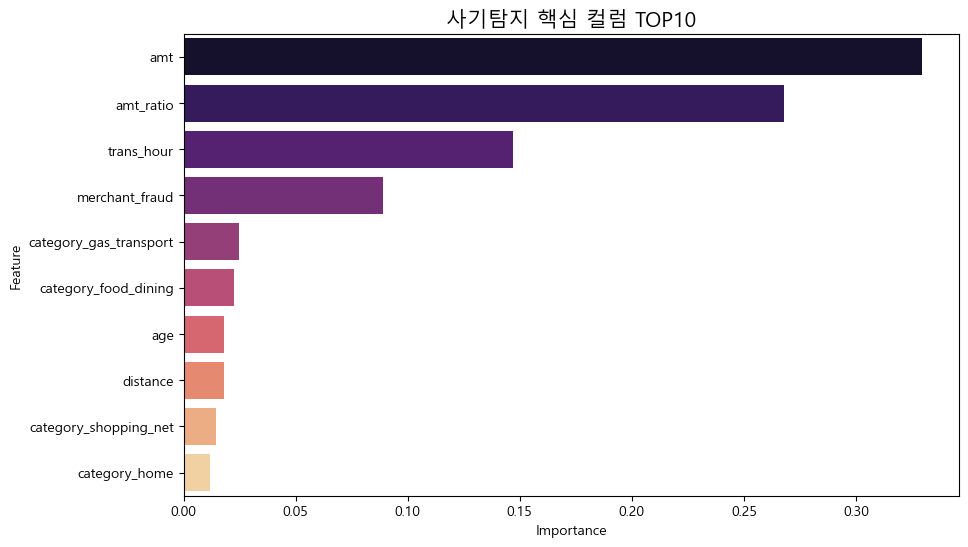

In [32]:
# 막대그래프로 보는 컬럼별 사기탐지 기여도
plt.figure(figsize=(10, 6))
importance_df = pd.DataFrame({
    'Feature': x_test.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(x='Importance', y='Feature', data=importance_df.head(10), palette='magma')
plt.title('사기탐지 핵심 컬럼 TOP10', fontsize=15)
plt.show()

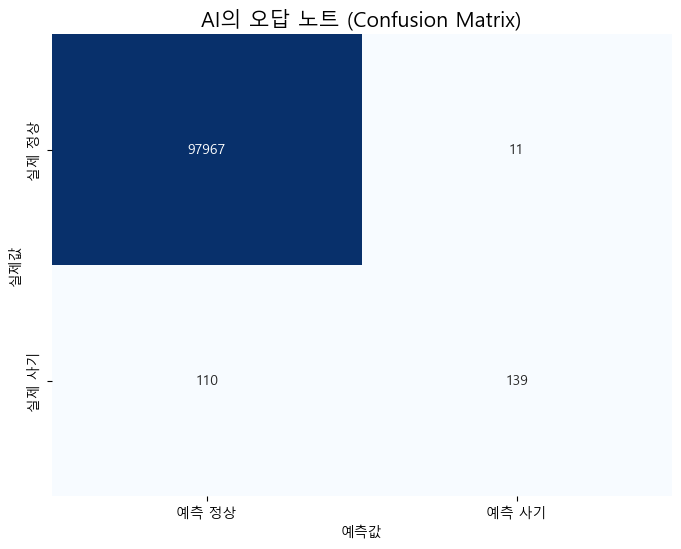

In [28]:
# 히트맵으로  예측값, 실제값 비교
plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, model.predict(x_test))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['예측 정상', '예측 사기'], 
            yticklabels=['실제 정상', '실제 사기'])
plt.title('AI의 오답 노트 (Confusion Matrix)', fontsize=15)
plt.xlabel('예측값')
plt.ylabel('실제값')
plt.show()

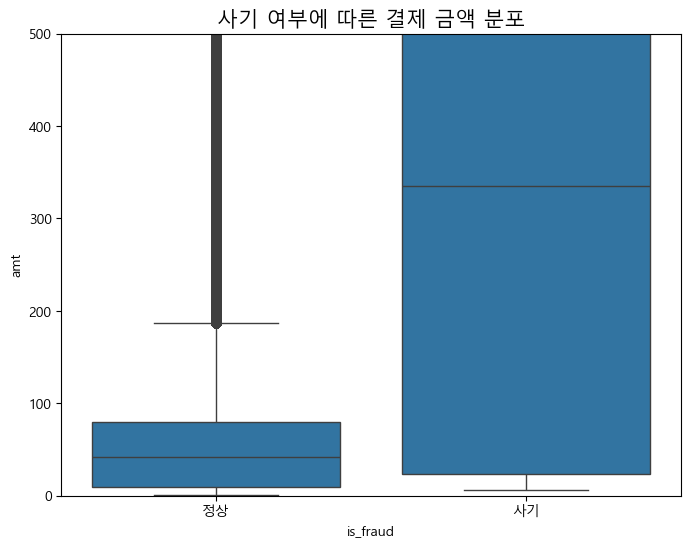

In [33]:
# 박스플롯 사기거래와 정상거래의 결제금액(amt) 차이를 시각화
plt.figure(figsize=(8, 6))
sns.boxplot(x='is_fraud', y='amt', data=df)
plt.ylim(0, 500) # 금액이 너무 큰 이상치 때문에 분포가 박스가 찌그러지는것을 방지
plt.title('사기 여부에 따른 결제 금액 분포', fontsize=15)
plt.xticks([0, 1], ['정상', '사기'])
plt.show()

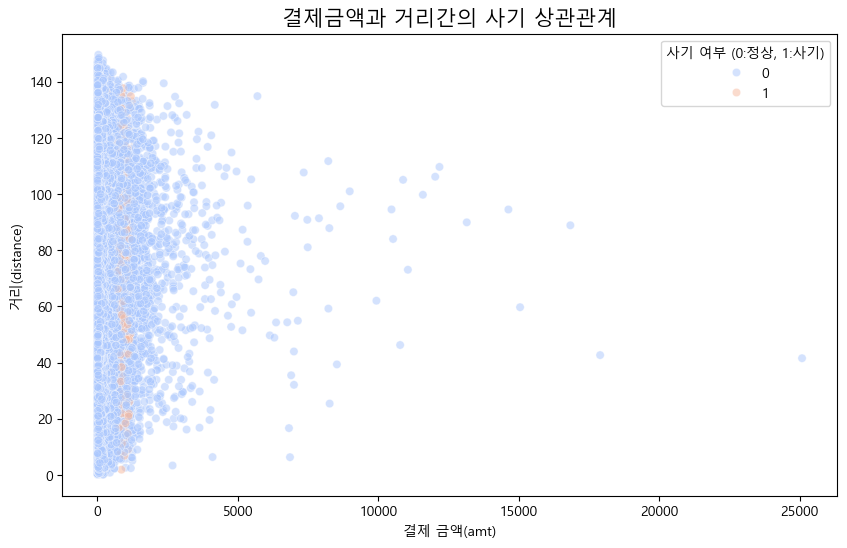

In [ ]:
# scatterplot 결제금액과 거리간의 사기 상관관계
plt.figure(figsize=(10, 6))
sns.scatterplot(x='amt', y='distance', hue='is_fraud', data=df, alpha=0.5, palette='coolwarm')

plt.title('결제금액과 거리간의 사기 상관관계', fontsize=15)
plt.xlabel('결제 금액')
plt.ylabel('거리')
plt.legend(title='사기 여부 (0:정상, 1:사기)')
plt.show()

In [38]:
from sklearn.metrics import accuracy_score, recall_score

# 머신러닝 예측시키기 / y_test는 실제값, y_pred 머신 예측값
y_pred = model.predict(x_test)

# 정확도와 탐지율 계산
accuracy = accuracy_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)

# 3. 계산된 점수를 출력합니다
print(f"모델 정확도: {accuracy*100:.2f}%")
print(f"사기 탐지율: {recall*100:.2f}%")

모델 정확도: 99.88%
사기 탐지율: 55.82%
